In [2]:
import sklearn
import shap

X, y = shap.datasets.california(n_points=1000)
X100 = shap.utils.sample(X, 100)

model = sklearn.linear_model.LinearRegression()
model.fit(X, y)

/Users/dariog/Projects/intro_to_shap/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LinearRegression()

In [3]:
print("Model coefficients:\n")
for i in range(X.shape[1]):
    print(X.columns[i], "=", model.coef_[i].round(5))

Model coefficients:

MedInc = 0.42563
HouseAge = 0.01033
AveRooms = -0.1161
AveBedrms = 0.66385
Population = 3e-05
AveOccup = -0.26096
Latitude = -0.46734
Longitude = -0.46272


Vertical line: average value of `MedInc`.
Horizontal line: expected (i.e., average) value of f(x):

$\mathbb{E}[f(x)] = \frac{1}{N} \sum_{i=1}^N y_i$.

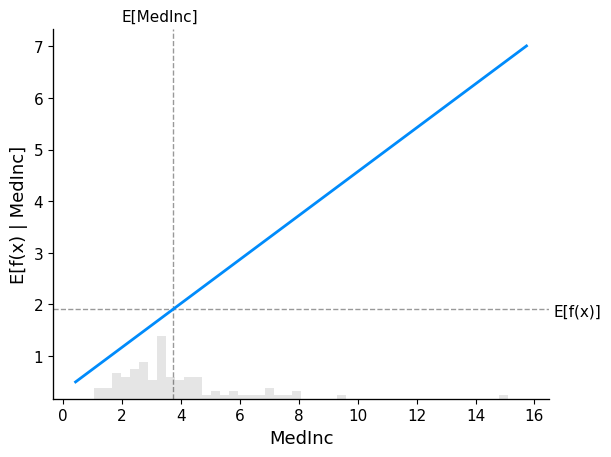

In [4]:
shap.partial_dependence_plot(
    "MedInc", model.predict, X100, ice=False, model_expected_value=True,
    feature_expected_value=True)

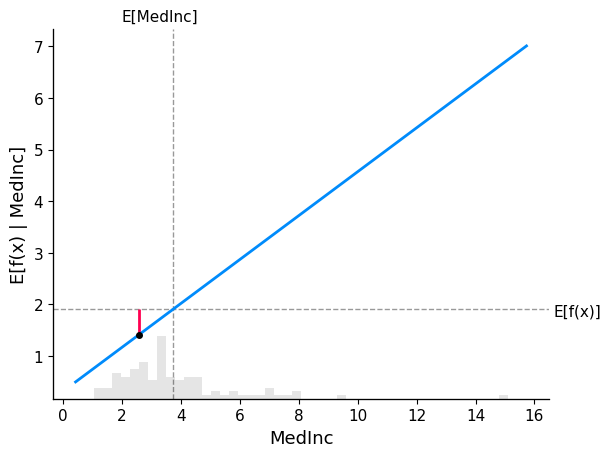

In [12]:
explainer = shap.Explainer(model.predict, X100)
shap_values = explainer(X)
sample_ind = 20
shap.partial_dependence_plot(
    "MedInc", model.predict, X100, ice=False, model_expected_value=True,
    feature_expected_value=True,
    shap_values=shap_values[sample_ind : sample_ind + 1, :])

AttributeError: 'Explanation' object has no attribute 'size'